No Pre-trained Weights: From Scratch

In [1]:
#Local Setup
import os

data_dir = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset"

Set-up

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import copy
import random
import numpy as np


batch_size = 32
num_classes = 500
num_epochs = 20
LR = 1e-4

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

Training on device: cuda:0


In [42]:
data_transform_none = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([          # exactly the same
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [43]:

# Augmented Data
data_transforms_fully_aug = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),    # takes a random patch of the photo and stretches it to 224×224. Half the image is a safer floor for fine-grained work.
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.3, hue=0.03),       # Requires Fine Tuning
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),    # blanks out a random rectangle after the image is a tensor
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms_fully_aug[x]) for x in ['train', 'val']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=batch_size, shuffle=(x == 'train'), num_workers=8, persistent_workers=True, pin_memory=True) for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

model = models.resnet50(weights='IMAGENET1K_V2')

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes) 
model = model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
class_names = image_datasets['train'].classes    # you'll need these later

In [ ]:
import pandas as pd

train_losses, val_losses = [], []
train_accs, val_accs = [], []

best_model_wts = copy.deepcopy(model.state_dict())                              # stored weights of the best model
best_acc = 0.0

print("Starting Experiment 1: ResNet50 From Pre-Trained Weights (Full Augmentation)")
for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')
    print('-' * 10)

    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()       # Uses current batch statistics
        else:           
            model.eval()        # Uses running averages

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()       # Clears gradients

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)         # 32 Images as Input, 32 x 500 grid, where each image golds the score for all 500 species
                _, preds = torch.max(outputs, 1)    # Minds the maximum score from the 500 row, returns score value and position - position correlates directly to the actual species
                loss = criterion(outputs, labels)

                # Actual physical training
                if phase == 'train':
                    loss.backward()     # Calculates what direction the model should moves to reduce the loss
                    optimizer.step()    # Actualy moves the weights by amount (learning rate)

            running_loss += loss.item() * inputs.size(0)        #average loss for that batch
            running_corrects += torch.sum(preds == labels.data) #Sum of all predictions that were correct

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = (running_corrects.double() / dataset_sizes[phase]).item()

        print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accs.append(epoch_acc)
        else:
            val_losses.append(epoch_loss)
            val_accs.append(epoch_acc)

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), r'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Checkpoint\{RUN_ID}_best.pth')

    print()

    pd.DataFrame({
        'epoch': range(1, len(train_losses) + 1),
        'train_loss': train_losses, 'train_acc': train_accs,
        'val_loss': val_losses, 'val_acc': val_accs,
    }).to_csv(r'C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\Checkpoint\{RUN_ID}_history.csv', index=False)

    scheduler.step()

model.load_state_dict(best_model_wts)

print(f'Experiment 1 Complete. Best Validation Accuracy: {best_acc:.4f}')

Starting Experiment 1: ResNet50 From Pre-Trained Weights (Full Augmentation)
Epoch 1/20
----------
Train Loss: 4.2709 Acc: 0.2681
Val Loss: 2.7083 Acc: 0.5478

Epoch 2/20
----------
Train Loss: 2.4665 Acc: 0.6282
Val Loss: 2.2350 Acc: 0.6672

Epoch 3/20
----------
Train Loss: 2.0063 Acc: 0.7440
Val Loss: 2.0709 Acc: 0.7118

Epoch 4/20
----------
Train Loss: 1.7636 Acc: 0.8155
Val Loss: 1.9636 Acc: 0.7432

Epoch 5/20
----------
Train Loss: 1.5973 Acc: 0.8606
Val Loss: 1.9416 Acc: 0.7502

Epoch 6/20
----------
Train Loss: 1.4838 Acc: 0.8931
Val Loss: 1.9007 Acc: 0.7634

Epoch 7/20
----------
Train Loss: 1.3903 Acc: 0.9217
Val Loss: 1.8618 Acc: 0.7702

Epoch 8/20
----------
Train Loss: 1.3244 Acc: 0.9414
Val Loss: 1.8454 Acc: 0.7728

Epoch 9/20
----------
Train Loss: 1.2715 Acc: 0.9546
Val Loss: 1.8289 Acc: 0.7826

Epoch 10/20
----------
Train Loss: 1.2281 Acc: 0.9650
Val Loss: 1.8148 Acc: 0.7886

Epoch 11/20
----------


Loss/ Accuracy Curves

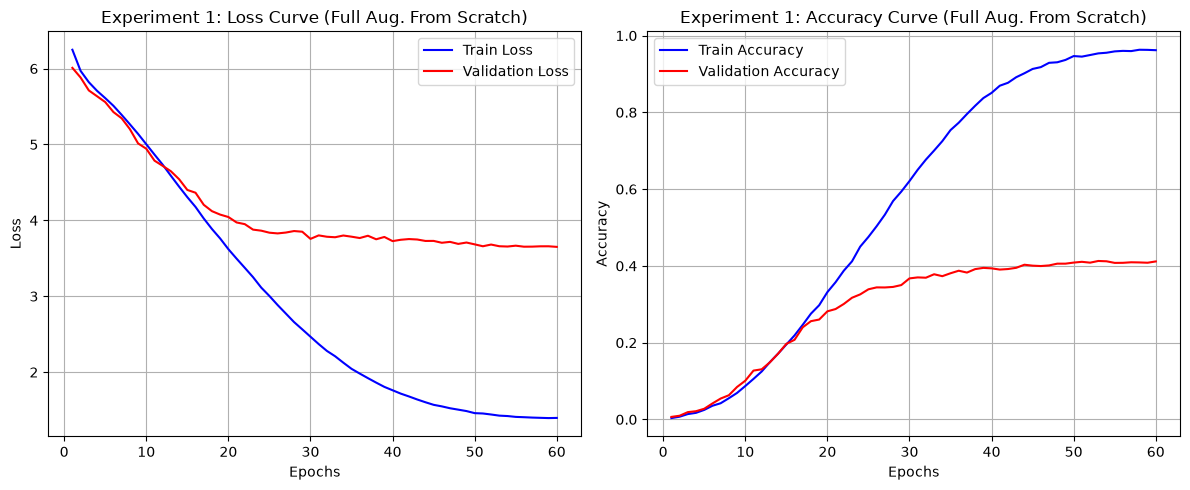

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Subplot 1: Loss Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, num_epochs+1), val_losses, label='Validation Loss', color='red')
plt.title('Experiment 1: Loss Curve (Full Aug. From Pre-trained)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Accuracy Curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), train_accs, label='Train Accuracy', color='blue')
plt.plot(range(1, num_epochs+1), val_accs, label='Validation Accuracy', color='red')
plt.title('Experiment 1: Accuracy Curve (Full Aug. From Pre-Trained)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Performance Metric Prep.

In [ ]:
import os, time, numpy as np, pandas as pd, torch

CKPT = r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ResNet50\Pre-Trained"
RUN_ID = 'r50_Pre_Full_Aug'
EVAL_SPLIT = 'test'       

# model.load_state_dict(torch.load(os.path.join(CKPT, 'exp1_scratch_best.pth')))
# model = model.to(device)

eval_ds = datasets.ImageFolder(os.path.join(data_dir, EVAL_SPLIT), data_transforms_fully_aug['val'])
eval_dl = DataLoader(eval_ds, batch_size=batch_size, shuffle=False, num_workers=2)
class_names = eval_ds.classes

model.eval()
all_top5, all_conf = [], []

if device.type == 'cuda': torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for inputs, _ in eval_dl:
        probs = model(inputs.to(device)).softmax(1)
        conf, top5 = probs.topk(5, dim=1)
        all_top5.append(top5.cpu())
        all_conf.append(conf[:, 0].cpu())

if device.type == 'cuda': torch.cuda.synchronize()
infer_secs = time.time() - t0

top5 = torch.cat(all_top5).numpy()

df = pd.DataFrame({
    'filepath':   [p for p, _ in eval_ds.samples],
    'true':       [y for _, y in eval_ds.samples],
    'pred':       top5[:, 0],
    'confidence': torch.cat(all_conf).numpy(),
})
for k in range(5):
    df[f'top{k+1}'] = top5[:, k]

df.to_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'), index=False)
print(f'{len(df)} images in {infer_secs:.1f}s  ({infer_secs*1000/len(df):.2f} ms/image)')

5000 images in 11.6s  (2.31 ms/image)


Numerical Performance Metric

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score

df = pd.read_csv(os.path.join(CKPT, f'{RUN_ID}_predictions.csv'))

top1 = (df['pred'] == df['true']).mean()

top5_cols = [f'top{k}' for k in range(1, 6)]
top5_acc = (df[top5_cols].values == df['true'].values[:, None]).any(axis=1).mean()

p, r, f1, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average='macro', zero_division=0)
bal = balanced_accuracy_score(df['true'], df['pred'])

print(f"Top-1 accuracy  : {top1:.4f}")
print(f"Top-5 accuracy  : {top5_acc:.4f}")
print(f"Balanced acc    : {bal:.4f}")
print(f"Macro precision : {p:.4f}")
print(f"Macro recall    : {r:.4f}")
print(f"Macro F1        : {f1:.4f}")

# one row per experiment, appended to a growing table
summary_path = os.path.join(r"C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\ResNet50\From Scratch\summary.csv")
pd.DataFrame([{
    'run': RUN_ID, 'arch': 'resnet50', 'augmentation': 'Full',
    'epochs': num_epochs, 'top1': top1, 'top5': top5_acc, 'balanced_acc': bal,
    'macro_p': p, 'macro_r': r, 'macro_f1': f1,
    'best_val_acc': best_acc, 'ms_per_img': infer_secs * 1000 / len(df),
}]).to_csv(summary_path, mode='a', header=not os.path.exists(summary_path), index=False)

Top-1 accuracy  : 0.4122
Top-5 accuracy  : 0.6246
Balanced acc    : 0.4122
Macro precision : 0.4217
Macro recall    : 0.4122
Macro F1        : 0.4069


Confusion Matric and Worst Species Pairs

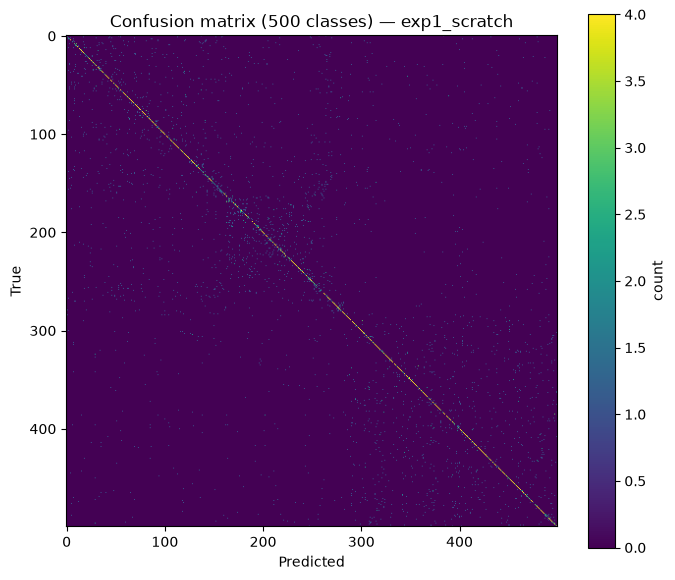


count  true species  →  predicted as
    6  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea  →  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica
    6  04275_Animalia_Chordata_Aves_Passeriformes_Turdidae_Sialia_sialis  →  04274_Animalia_Chordata_Aves_Passeriformes_Turdidae_Sialia_mexicana
    3  07067_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_missurica  →  07066_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Vernonia_gigantea
    3  05920_Plantae_Tracheophyta_Liliopsida_Asparagales_Asparagaceae_Polygonatum_biflorum  →  06195_Plantae_Tracheophyta_Liliopsida_Liliales_Melanthiaceae_Trillium_cernuum
    3  06771_Plantae_Tracheophyta_Magnoliopsida_Asterales_Asteraceae_Erigeron_canadensis  →  07280_Plantae_Tracheophyta_Magnoliopsida_Brassicales_Brassicaceae_Thlaspi_arvense
    3  07950_Plantae_Tracheophyta_Magnoliopsida_Fabales_Fabaceae_Desmanthus_illinoensis  →  09932_Plantae_Tracheophyta_Polypo

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(df['true'], df['pred'], labels=range(num_classes))

plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap='viridis', vmax=np.percentile(cm, 99.9))
plt.colorbar(label='count')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion matrix ({num_classes} classes) — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_confusion.png'), dpi=150)
plt.show()

off = cm.copy()
np.fill_diagonal(off, 0)
rows, cols = np.unravel_index(np.argsort(off, axis=None)[::-1][:15], off.shape)

print("\ncount  true species  →  predicted as")
for a, b in zip(rows, cols):
    print(f"{off[a,b]:5d}  {class_names[a]}  →  {class_names[b]}")

per-class F1 and Failure Examples

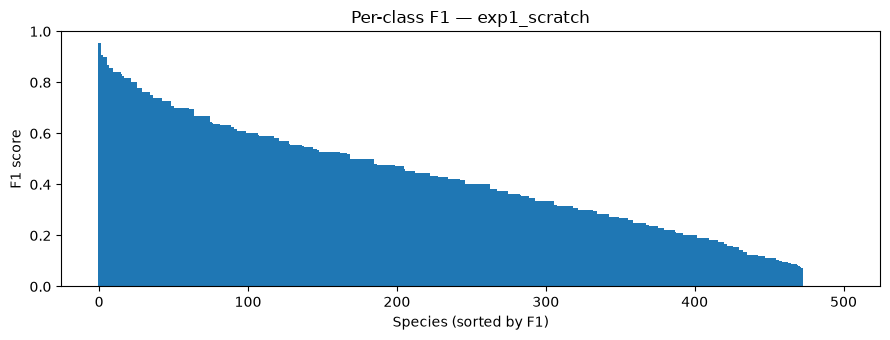

Species never correctly identified: 27 / 500

Most confident mistakes:
0.99  05653_Fungi_Basidiomycota_Agaricomycetes_Polyporales_Fomitopsidaceae_Fomitopsis_mounceae  called  03105_Animalia_Chordata_Amphibia_Caudata_Salamandridae_Taricha_sierrae
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\05653_Fungi_Basidiomycota_Agaricomycetes_Polyporales_Fomitopsidaceae_Fomitopsis_mounceae\7d5fb17c-d351-4eb9-ad54-db5f8b0617d4.jpg
0.98  05585_Fungi_Basidiomycota_Agaricomycetes_Agaricales_Strophariaceae_Pholiota_squarrosa  called  05662_Fungi_Basidiomycota_Agaricomycetes_Polyporales_Laetiporaceae_Laetiporus_sulphureus
      C:\Users\alexs\Desktop\UNSW\2026T2\COMP9517\COMP9517_Team_500_40_10\content/Team_Dataset\test\05585_Fungi_Basidiomycota_Agaricomycetes_Agaricales_Strophariaceae_Pholiota_squarrosa\6c6d1959-8e4f-4ba9-8c58-fe81033ce9e6.jpg
0.98  04113_Animalia_Chordata_Aves_Passeriformes_Passerellidae_Passerella_iliaca  called  04127_Animalia_Ch

In [39]:
_, _, f1_per, _ = precision_recall_fscore_support(
    df['true'], df['pred'], average=None, labels=range(num_classes), zero_division=0)

plt.figure(figsize=(9, 3.5))
plt.bar(range(num_classes), np.sort(f1_per)[::-1], width=1.0)
plt.xlabel('Species (sorted by F1)'); plt.ylabel('F1 score')
plt.title(f'Per-class F1 — {RUN_ID}')
plt.tight_layout()
plt.savefig(os.path.join(CKPT, f'{RUN_ID}_perclass_f1.png'), dpi=150)
plt.show()

print(f"Species never correctly identified: {(f1_per == 0).sum()} / {num_classes}")

print("\nMost confident mistakes:")
for _, row in df[df.pred != df.true].nlargest(10, 'confidence').iterrows():
    print(f"{row.confidence:.2f}  {class_names[row.true]}  called  {class_names[row.pred]}")
    print(f"      {row.filepath}")